# CodeAlpha: Exploratory Data Analysis (EDA) on Amazon Sales Data

**Objective:** To perform comprehensive Exploratory Data Analysis (EDA) on an e-commerce dataset to identify trends, clean data issues, test hypotheses, and extract business insights.

---
### Step 1: Loading the Dataset

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Amazon sales data (Ensure the filename matches exactly)
df = pd.read_csv('Amazon Sale Report.csv', low_memory=False)

# Display the first 5 rows to confirm the data has loaded successfully
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


### Step 2: Exploring Data Structure and Detecting Issues

In [2]:
# Check the data structure and data types
print("Data Structure:")
df.info()

print("\n" + "-" * 50 + "\n")

# Check for missing (null) values in each column
print("Missing Values Before Cleaning:")
print(df.isnull().sum())

Data Structure:
<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 no

### Step 3: Data Cleaning
Handling missing values and removing unnecessary columns to ensure accurate analysis.

In [3]:
# Drop unnecessary columns with a high percentage of missing values
columns_to_drop = ['Unnamed: 22', 'fulfilled-by', 'promotion-ids']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Drop rows where the 'Amount' is missing (as revenue analysis requires this)
df.dropna(subset=['Amount'], inplace=True)

# Fill missing values in text (string) columns with 'Unknown'
string_columns = df.select_dtypes(include=['object']).columns
df[string_columns] = df[string_columns].fillna('Unknown')

# Fill missing values in numeric columns with 0
numeric_columns = df.select_dtypes(include=['number']).columns
df[numeric_columns] = df[numeric_columns].fillna(0)

# Verify that the data is completely clean
print("Data Cleaning Complete! Missing values after cleaning:")
print(df.isnull().sum())

Data Cleaning Complete! Missing values after cleaning:
index                 0
Order ID              0
Date                  0
Status                0
Fulfilment            0
Sales Channel         0
ship-service-level    0
Style                 0
SKU                   0
Category              0
Size                  0
ASIN                  0
Courier Status        0
Qty                   0
currency              0
Amount                0
ship-city             0
ship-state            0
ship-postal-code      0
ship-country          0
B2B                   0
dtype: int64


C:\Users\Abdur Rahman\AppData\Local\Temp\ipykernel_7140\3472774008.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_columns = df.select_dtypes(include=['object']).columns


### Step 4: Identifying Trends - Order Volume by Category

C:\Users\Abdur Rahman\AppData\Local\Temp\ipykernel_7140\756588012.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, palette='viridis')


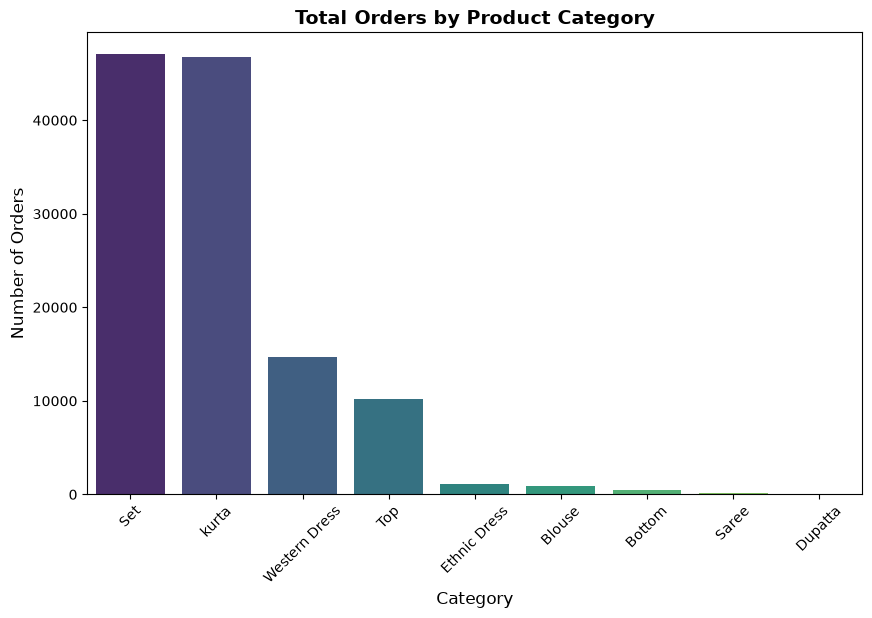

In [4]:
# Set the figure size for the plot
plt.figure(figsize=(10, 6))

# Plot the total number of orders by product category
sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index, palette='viridis')

# Add titles and labels for better readability
plt.title('Total Orders by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45) # Rotate x-axis labels to prevent overlap
plt.show()

### Step 5: Hypothesis Testing - Orders vs. Revenue
**Hypothesis:** The product categories generating the highest order volume also generate the most revenue.

C:\Users\Abdur Rahman\AppData\Local\Temp\ipykernel_7140\1945590957.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_category.index, y=revenue_by_category.values, palette='magma')


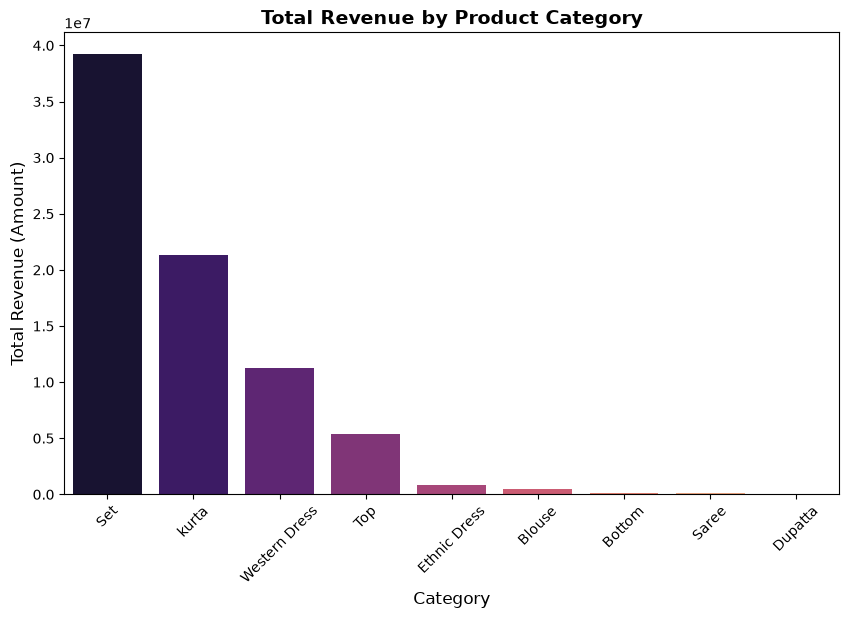

In [5]:
# Calculate total revenue (Amount) grouped by Category
revenue_by_category = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

# Set the figure size and style
plt.figure(figsize=(10, 6))

# Plot the revenue data as a bar chart
sns.barplot(x=revenue_by_category.index, y=revenue_by_category.values, palette='magma')

# Add titles and labels
plt.title('Total Revenue by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Revenue (Amount)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Step 6: Time Series Analysis - Daily Sales Trend

C:\Users\Abdur Rahman\AppData\Local\Temp\ipykernel_7140\3790651134.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


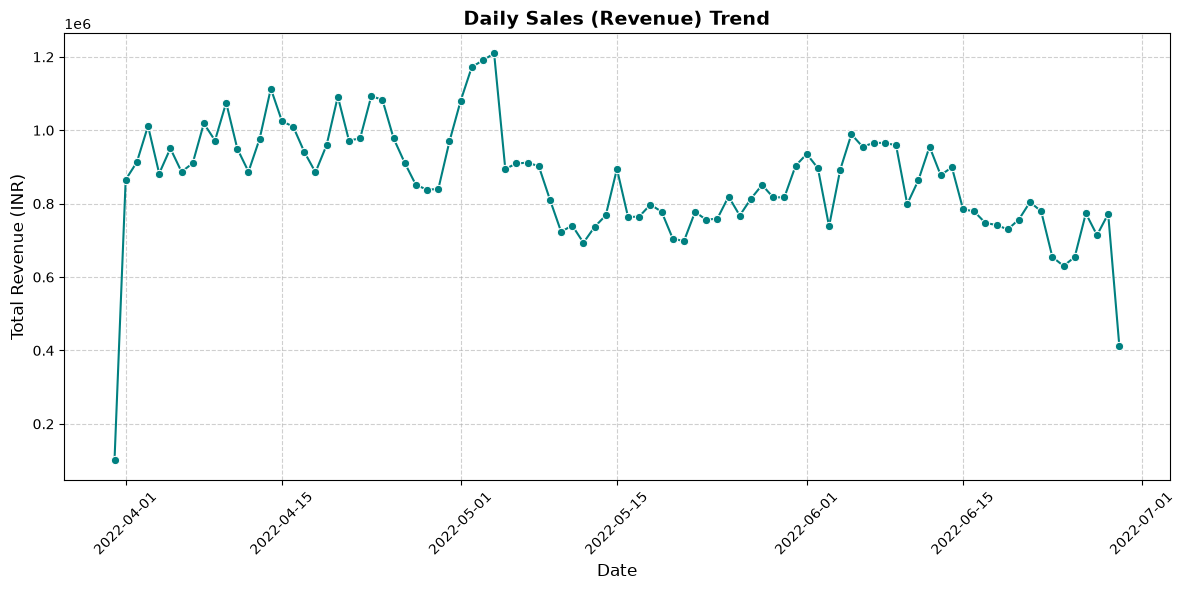

In [6]:
# 1. Convert the 'Date' column to proper datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# 2. Calculate the total revenue aggregated by day
daily_revenue = df.groupby(df['Date'].dt.date)['Amount'].sum()

# 3. Set the figure size
plt.figure(figsize=(12, 6))

# 4. Create a line plot to visualize the daily sales trend
sns.lineplot(x=daily_revenue.index, y=daily_revenue.values, color='teal', marker='o')

# 5. Format the graph for better visualization
plt.title('Daily Sales (Revenue) Trend', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Revenue (INR)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6) # Add grid lines for easier reading
plt.tight_layout()
plt.show()